# ABSTRACT
-------------------------------------------------------------
Heart disease is one of the most critical health problems worldwide, and early prediction can significantly reduce serious medical risks.The goal of this project is to build a machine learning model using Logistic Regression to classify whether a patient has heart disease or not based on important medical attributes.** The dataset used in this project is a multivariate heart disease dataset derived from the Cleveland Heart Disease Database. Although the originaldata contains 76 medical features, this project focuses on the widely used subset of 14 attributes, including age, sex, chest pain type, resting blood pressure,cholesterol level, fasting blood sugar, electrocardiographic results, maximum heart rate, exercise-induced angina, ST depression (oldpeak), slope of the ST segment, the number of major vessels, and thalassemia. These features represent essential clinical indicators that help analyze a patient’s cardiovascular condition.** In this study, Logistic Regression is chosen as the primary algorithm because it is simple, interpretable, efficient for binary classification, and commonly used for medical diagnosis tasks. The project includes data preprocessing, handling missing values, encoding categorical variables, feature scaling, model training, and evaluation. The performance of the model is assessed using accuracy, precision, recall, F1-score, and a confusion matrix. These evaluation metrics help understand how effectively the model identifies both healthy and heart-disease patients. The results show that Logistic Regression can provide reliable baseline predictions and serve as a useful tool in supporting early diagnosis. This project demonstrates how machine learning—especially Logistic Regression—can assist healthcare professionals in making informed decisions and identifying heart disease risk at an early stage. yeslai pani nepali ma lekhdinus

--------------------------------------------------------
<div style= "justify-content:center"> 

###  📂 Dataset Information

यो project मा Cleveland Heart Disease Database बाट लिइएको dataset प्रयोग गरिएको छ।
Original dataset मा 76 वटा medical attributes भए पनि, यो study मा clinically लोकप्रिय 14 features (parameters) मात्र राखिएको छ।

यी 14 features मा समावेश छन्:

* age

* sex

* chest pain type (cp)

* resting blood pressure (trestbps)

* cholesterol (chol)

* fasting blood sugar (fbs)

* resting electrocardiographic results (restecg)

* maximum heart rate achieved (thalach)

* exercise-induced angina (exang)

* ST depression (oldpeak)

* slope of the ST segment (slope)

* number of major vessels (ca)

* thalassemia (thal)

यी सबै clinical indicators ले patient को cardiovascular status को मूल्याङ्कन गर्न मद्दत गर्छन्।

###  🤖 Why Logistic Regression?

यो project मा Logistic Regression रोजिएको छ किनकि:

* Simple र बुझ्न सजिलो

* Medical diagnosis जस्ता binary classification tasks मा धेरै उपयुक्त

* Computationally efficient

* Model को explanation (interpretability) राम्रो


###  🔧 Preprocessing Steps

मोडेल Train गर्नुअघि dataset मा निम्न कार्यहरू गरियो:

* Missing values को handling

* Categorical variables को encoding

* Feature scaling (normalization/standardization)

* Train-test split

* Logistic Regression model training


###  📊 Model Evaluation Metrics

मोडेलको performance हेर्न निम्न evaluation metrics प्रयोग गरियो:

* Accuracy

* Precision

* Recall

* F1-score

* Confusion Matrix

यी metrics ले model ले

* Heart disease नभएका (0 class)

* Heart disease भएका (1 class)

दुवै patient लाई कति राम्रो classify गर्यो भन्ने बुझ्न मद्दत गर्छ।
 </div>

------------------------------------------------------------------------

In [2]:
import pandas as pd
import os 

In [3]:
df = pd.read_csv("./dataset/heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


### Column Descriptions:
* id (Unique id for each patient)
* age (Age of the patient in years)
* origin (place of study)
* sex (Male/Female)
* cp chest pain type ([typical angina, atypical angina, non-anginal, asymptomatic])
* trestbps resting blood pressure (resting blood pressure (in mm Hg on admission to the hospital))
* chol (serum cholesterol in mg/dl)
* fbs (if fasting blood sugar > 120 mg/dl)
* restecg (resting electrocardiographic results)
-- Values: [normal, stt abnormality, lv hypertrophy]
* thalach: maximum heart rate achieved
* exang: exercise-induced angina (True/ False)
* oldpeak: ST depression induced by exercise relative to rest
* slope: the slope of the peak exercise ST segment
* ca: number of major vessels (0-3) colored by fluoroscopy
* thal: [normal; fixed defect; reversible defect]
* num: the predicted attribute


1. typical angina :  छातीको बीचमा दुख्ने / दौड्दा/चढ्दा दुखाइ बढ्ने / बस्दा/आराम गर्दा वा औषधि खाँदा कम हुने (यो मुटुको समस्या (heart attack/cardiac block) हुन सक्छ।)
2. atypical angina : छाती दुख्छ तर कहिलेकाहीँ / कहिले exertion मा दुख्छ, कहिले होतैन / आरामले कहिले कम हुन्छ, कहिले होतैन (मुटुको समस्या हुन पनि सक्छ, नहुन पनि सक्छ (बीचमा))
3. Non-anginal : चिलाउने, चस्स गर्ने, टोक्किने, एक ठाउँमा मात्र / हल्लिँदा, सास फेर्दा, छाम्दा पनि दुख्ने / लामो समय रहिरहने (मुटुको समस्या होइन – gastritis, muscle pull, anxiety आदि।)
4. Asymptomatic : Diabetes भएका, बुढाबुढीमा धेरै देखिन्छ /Test गर्दा मात्र पत्ता लाग्छ।

In [12]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


#### Categorical Columns ? 
* sex 
* dataset 
* cp
* fbs
* restecg
* exang
* slope
* thal
#### Numeric Columns ? 
* id 
* age
* trestbps
* chol
* thalch
* oldpeak   
* ca
* num
#### Missing values?
* Trestbps
* chol
* fbs
* restecg
* thalch  
* exang     
* oldpeak   
* slope     
* ca        
* thal     

## Missing value Analysis

###

In [20]:
# Missing value number 
df.isna().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [21]:
# Missing value percentage
df.isnull().sum()/ df.shape[0]*100

id           0.000000
age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
trestbps     6.413043
chol         3.260870
fbs          9.782609
restecg      0.217391
thalch       5.978261
exang        5.978261
oldpeak      6.739130
slope       33.586957
ca          66.413043
thal        52.826087
num          0.000000
dtype: float64

## Statical Summary(Numerical EDA)

In [24]:
num_data = df.select_dtypes(include=['int','float'])
num_data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,920.0,460.500000,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,53.510870,9.424685,28.0,47.00,54.0,60.00,77.0
trestbps,861.0,132.132404,19.066070,0.0,120.00,130.0,140.00,200.0
chol,890.0,199.130337,110.780810,0.0,175.00,223.0,268.00,603.0
thalch,865.0,137.545665,25.926276,60.0,120.00,140.0,157.00,202.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.00,0.5,1.50,6.2
ca,309.0,0.676375,0.935653,0.0,0.00,0.0,1.00,3.0
num,920.0,0.995652,1.142693,0.0,0.00,1.0,2.00,4.0


* Age => Dataset मा patient को उमेर middle-age group (47–60) मा बढी छ।
* Trestbps(Resting Blood Pressure) => Missing : 920 - 861 = 59 Rows missing , Normal BP ～120, mean : 132  -> high BP Tendency.
* Chol(Cholesterol) => Cholesterol मा outlier presence छ (max 603)।  value is wrong messurement or missing 

# Statical Summarry(Categorical EDA)

In [10]:
# categorical value count each column 
for col in df.select_dtypes(include= ['object']).columns:
    print(col, "================================================>")
    print(df[col].value_counts(), "\n")

sex ================================================>
sex
Male      726
Female    194
Name: count, dtype: int64 

dataset ================================================>
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64 

cp ================================================>
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64 

fbs ================================================>
fbs
False    692
True     138
Name: count, dtype: int64 

restecg ================================================>
restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
Name: count, dtype: int64 

exang ================================================>
exang
False    528
True     337
Name: count, dtype: int64 

slope ================================================>
slope
flat           345
upsloping      203
downsloping     63
Name: count, dtype:

####  🔍 1. sex (लिङ्ग)
Category	Count <br>
Male	726 <br>
Female	194 <br>

👉 पुरुषको संख्या धेरै छ (≈ 79%) <br>
👉 महिलाको संख्या कम छ (≈ 21%) <br>

#### 🔍 2. dataset (मूल hospital dataset स्रोत)
Dataset	Count<br>
Cleveland	304<br>
Hungary	293<br>
VA Long Beach	200<br>
Switzerland	123<br>

👉 सबैभन्दा धेरै Cleveland dataset बाट छ।<br>
👉 सबै dataset मिसाएर बनेको combined heart-disease dataset हो।<br>

#### 🔍 3. cp (Chest Pain प्रकार)

Chest pain (cp) का चार प्रकार हुन्छन्: <br>

Chest Pain Type	Count	Meaning (Nepali)<br>
asymptomatic	496	लक्षण नदेखिने तर ECG मा समस्या<br>
non-anginal	204	हृदयसम्बन्धी नभएको दुखाइ<br>
atypical angina	174	अनौठो तर हृदयसँग सम्बन्धित हुनसक्ने<br>
typical angina	46	सामान्य cardiac chest pain<br>

👉 asymptomatic सबैभन्दा धेरै छ → धेरै बिरामी बाहिरी लक्षण नभएका छन्।

#### 🔍 4. fbs (Fasting Blood Sugar >120 mg/dl)
Value	Count	Meaning <br>
False	692	सामान्य स्तर<br>
True	138	उच्च sugar (diabetes risk)<br>

👉 उच्च sugar भएका बिरामी ~138 (≈16%)।

#### 🔍 5. restecg (Resting ECG Result)
Type	Count	Meaning<br>
normal	551	ECG सामान्य<br>
lv hypertrophy	188	Left ventricle मोटोपन (pressure issue)<br>
st-t abnormality	179	ST/T wave abnormal – ischemia indication<br>

👉 ECG सामान्य धेरैमा छ (~551)।

#### 🔍 6. exang (Exercise-Induced Angina)
Value	Count	Meaning<br>
False	528	exercise गर्दा chest pain छैन<br>
True	337	exercise गर्दा pain (angina) छ<br>

👉 True (yes pain) पनि धेरै छ → हृदयसम्बन्धी समस्या संकेत।

#### 🔍 7. slope (Peak ST segment slope)
Type	Count<br>
flat	345<br>
upsloping	203<br>
downsloping	63<br>

👉 flat सबभन्दा risk-indicating pattern हो (बहुत ज्यादा patients मा छ)।<br>
👉 downsloping पनि high risk मा पर्छ तर कम छ (63 जना)।

#### 🔍 8. thal (Thalassemia Test Result)
Type	Count	Meaning<br>
normal	196	कुनै defect छैन<br>
reversable defect	192	stress मा defect देखिन्छ – ischemia संकेत<br>
fixed defect	46	स्थायी defect – पुरानो damage<br>

👉 normal र reversible defect लगभग बराबर।<br>
👉 fixed defect कम (~46).

#### ✅ Short Summary

Dataset मा पुरुष धेरै छन्।

Chest pain मा asymptomatic धेरै (लक्षण बाहिर नदेखिने)।

Exercise गर्दा pain हुने (exang=True) 337 cases छन्।

Slope = flat धेरै → risk संकेत।

Thal test मा normal र reversible defect लगभग बराबर।

# Visualization
### Target Distribution(Heart Disease Frequency)

In [11]:
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


<Axes: xlabel='num'>

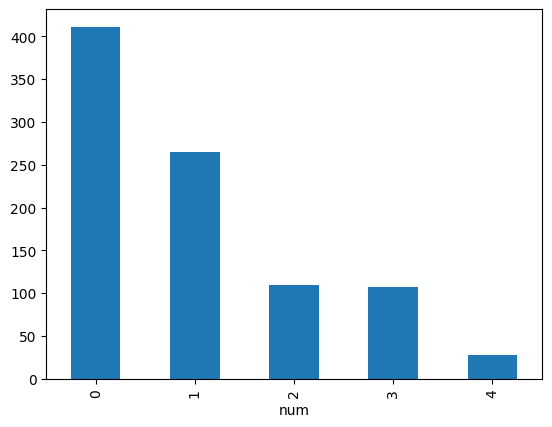

In [ ]:
df['num'].value_counts().plot(kind='bar',)

* 0: No Heart Disease 
* 1,2,3,4 : Disease severity 

In [14]:
df['target'] = df['num'].apply(lambda x: 1 if x> 0 else 0)

In [15]:
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2,1
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0,0


<Axes: xlabel='target'>

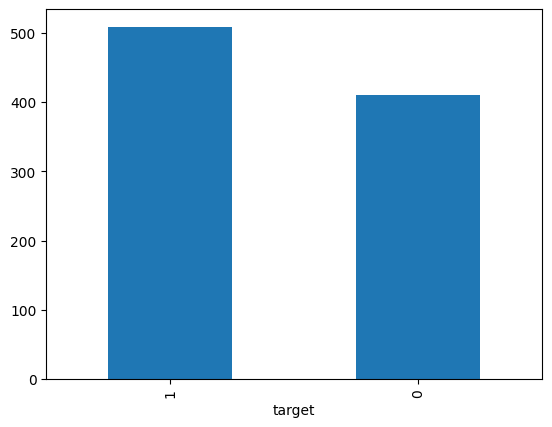

In [17]:
df['target'].value_counts().plot(kind='bar')

In [21]:
df.drop(columns='num', inplace=True)

#### Histogram 


array([[<Axes: title={'center': 'id'}>, <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'thalch'}>,
        <Axes: title={'center': 'oldpeak'}>],
       [<Axes: title={'center': 'ca'}>,
        <Axes: title={'center': 'target'}>, <Axes: >]], dtype=object)

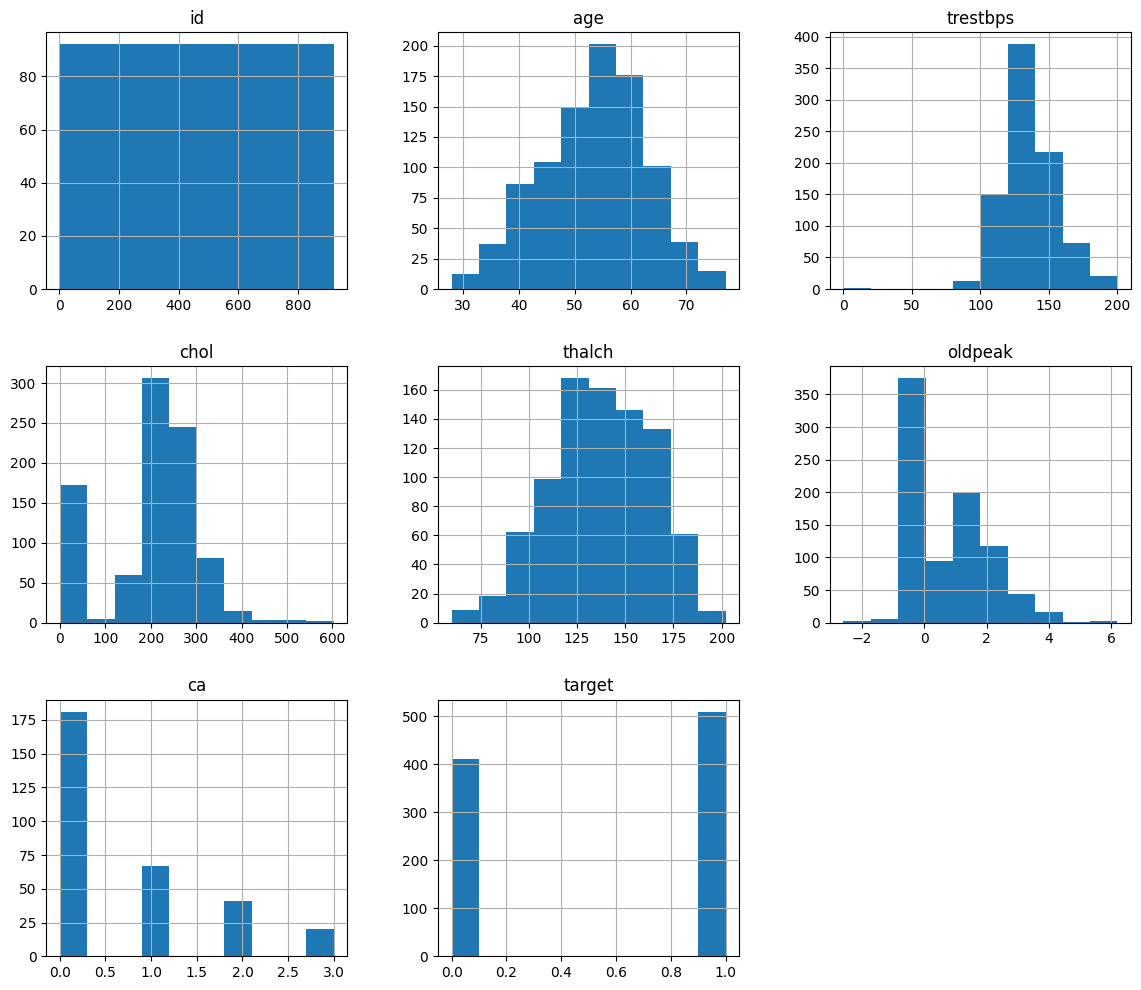

In [22]:
df.hist(figsize=(14,12))

#### 📊 1) id

Graph बिल्कुल flat uniform देखिन्छ।<br>

किनकि id एक identifier हो → analysis मा उपयोग हुने feature होइन।<br>

Histogram uniform हुनु नै normal हो (0–900 सम्म)।<br>
✔️ Conclusion: id लाई modeling बाट drop गर्नुपर्छ।<br>

#### 📊 2) age

Bell curve (normal distribution) नजिकको shape। <br>

Majority age = 50–60 years।<br>

30–80 age range।<br>
✔️ Conclusion: धेरै heart-disease patients middle-aged छन्। Age highly important predictive feature हो।<br>

### 📊 3) trestbps (resting blood pressure)

Majority data 120–150 mmHg।<br>

काही outliers 200 नजिक पनि छन्।<br>
✔️ Conclusion: BP सामान्य भन्दा उच्च देखिन्छ (hypertension pattern) → हृदय रोगसँग सम्बन्धित हुन्छ।<br>

#### 📊 4) chol (serum cholesterol)

Multi-peaked distribution (not normal)।<br>

Majority 150–300।<br>

Some extreme outliers 500+। <br>
✔️ Conclusion: Cholesterol मा variability धेरै छ। High cholesterol heart disease risk factor हो।<br>

#### 📊 5) thalch (maximum heart rate achieved)

Histogram सफा shape → majority 100–160।<br>

Peak ≈ 130–140।<br>
✔️ Conclusion: Exercise capacity (थाकेको बेला हृदय दर) heart disease prediction मा महत्त्वपूर्ण हुन्छ।<br>

#### 📊 6) oldpeak (ST depression induced by exercise)

Majority data 0–1.5 मा छ।<br>

Thoड़ा outliers 4–6 सम्म छन्।<br>
✔️ Conclusion: उच्च oldpeak (3+ above) भएका बिरामीमा ischemia suspicious हुन्छ।<br>

#### 📊 7) ca (number of major vessels colored by fluoroscopy)

0 vessels सर्वाधिक (≈ 180)।<br>

1, 2, 3 vessels क्रमशः घट्दै जान्छ।<br>
✔️ Conclusion: 'ca' feature highly predictive हो।<br>
0 means no major vessel blockage visible.<br>
3 means very high blockage signs.<br>

#### 📊 8) target (0 = no disease, 1 = disease)

लगभग balanced dataset जस्तो देखिन्छ:<br>

0 = ~420<br>

1 = ~500<br>
✔️ Conclusion: Dataset थोड़ी imbalance छ (not extreme) → Logistic Regression/Tree models राम्रो काम गर्छन्।<br>

### =========== 🔎 Overall Summary (जति graph छ सबैको meaning एकै ठाउँमा) ==============
|Feature|	Distribution Meaning|
|-------|-----------------------|
id|	identifier, drop गर्नुपर्छ|
|age|	Middle-age patients ज्यादा|
|trestbps|	High BP common|
|chol|	High cholesterol + outliers|
|thalch|	130–150 peak (exercise heart rate)|
|oldpeak|	0–1.5 common, some severe outliers|
|ca|	0 vessels most common → clean arteries|
|target|	0/1 almost balanced|

# Boxplot for OUtliers

AttributeError: module 'matplotlib.pyplot' has no attribute 'xtricks'

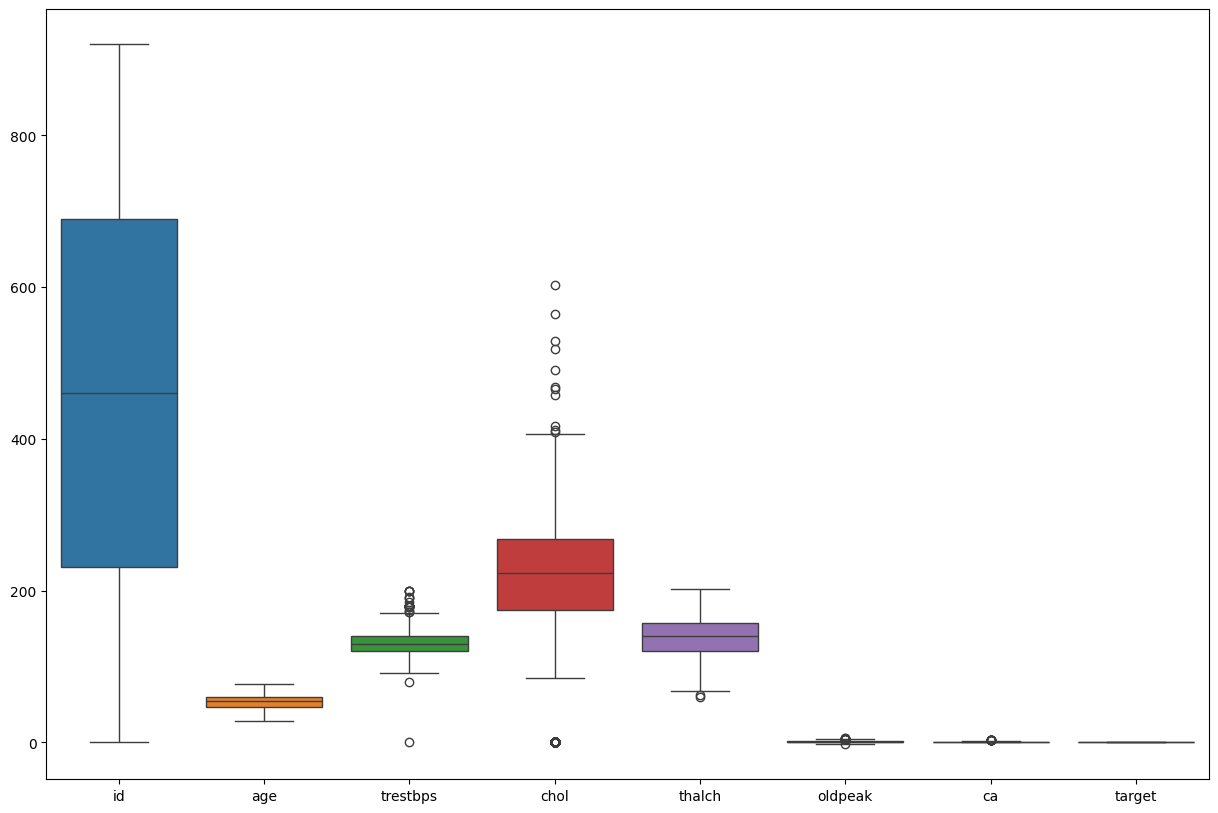

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (15,10))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xtricks(roation=90)
plt.show()